# Deutsch–Jozsa Algorithm

In this module, you will:
- Understand how the **Deutsch–Jozsa algorithm** determines whether a boolean function is **constant** or **balanced** in a **single query** to an oracle.
- Build the Deutsch–Jozsa circuit step-by-step using the QpiAI Quantum SDK, both **manually** with `Circuit` and via the high-level `DeutschJozsa` class.
- Analyze the **mathematical foundation**: Hadamard transforms, phase kickback, and interference.
- Run experiments on a **simulator** and verify that the measurement outcome correctly classifies the oracle.

## What is the Deutsch–Jozsa Algorithm?

Imagine you are given a black-box function (an *oracle*) $f:\{0,1\}^n \to \{0,1\}$ that is **promised** to be one of two types:

- **Constant:** $f(x)$ returns the same value (0 or 1) for **all** inputs $x$.
- **Balanced:** $f(x)$ returns 0 for **exactly half** of the inputs and 1 for the other half.

**The Challenge:** Given only oracle access to $f$, determine whether it is constant or balanced.

- **Classically**, a deterministic algorithm needs up to **$2^{n-1} + 1$ queries** in the worst case.
- **Quantumly**, the Deutsch–Jozsa algorithm answers the question in **just 1 query**: an exponential speedup.

**Key Insight:** The algorithm exploits two powerful quantum phenomena:
1. **Superposition**: querying the oracle with all inputs simultaneously.
2. **Phase kickback**: encoding the answer into the *phases* of the quantum state, which are then decoded by a second Hadamard transform and detected via interference.

## 1. Setup & Authentication

We reuse the same authentication pattern as previous modules: load `API_KEY` from `qcloud.env` and authenticate with `QpiAIQuantumAuth`.

In [1]:
import os

from dotenv import load_dotenv
from qpiai_quantum import QpiAIQuantumAuth

load_dotenv("./qcloud.env") # This path should point to the env file containing your API key.

QpiAIQuantumAuth.login(os.getenv("API_KEY"))
user_info = QpiAIQuantumAuth.me()

print(f"✅ Authenticated successfully as: {user_info.get('name', 'User')} ({user_info.get('email', '')})")

✅ Authenticated successfully as: Test Advanced User (test_advanced@qpiai.tech)


## 2. SDK Primitives Used (This Module)

- `DeutschJozsa`: high-level algorithm class that builds and runs the Deutsch–Jozsa circuit.
- `Circuit`: low-level circuit construction API (for manual circuit building).
- **Gates:** `h` (Hadamard), `x` (Pauli-X / NOT), `cx` (CNOT).
- **Circuit utilities:** `show()`, `list_gates()`.
- **Execution:** `Circuit.run(shots=..., device_name="QpiAI-QSV-Local") (Note: `experiment_name` is optional and only required for cloud executions)`.
- **Results:** `result.get_counts()`, `result.get_probabilities()`, `result.plot()`.

We will first build the circuit **manually** to understand each stage, then use the high-level `DeutschJozsa` class for convenience.

## 3. Code: Building the Deutsch–Jozsa Circuit

The Deutsch–Jozsa circuit has **five stages**:

1. **Ancilla preparation:** Apply $X$ then $H$ to the ancilla qubit to put it in the $|-\rangle$ state.
2. **Input superposition:** Apply $H$ to all $n$ input qubits to create a uniform superposition.
3. **Oracle:** Apply the oracle $U_f$. For a **balanced** oracle ($f(x) = x_0 \oplus x_1 \oplus \ldots \oplus x_{n-1}$), apply $\text{CX}(i, \text{ancilla})$ from every input qubit to the ancilla.
4. **Decoding:** Apply $H$ to all input qubits. The Hadamard transform converts phase information back into computational basis states.
5. **Measurement:** Measure the $n$ input qubits. The result deterministically reveals whether $f$ is constant or balanced.

### 3a. Manual Construction with `Circuit`

Let's build the Deutsch–Jozsa circuit for a **balanced** oracle with $n = 3$ input qubits.

=== Manual DJ Circuit (balanced oracle, n = 3 ) ===


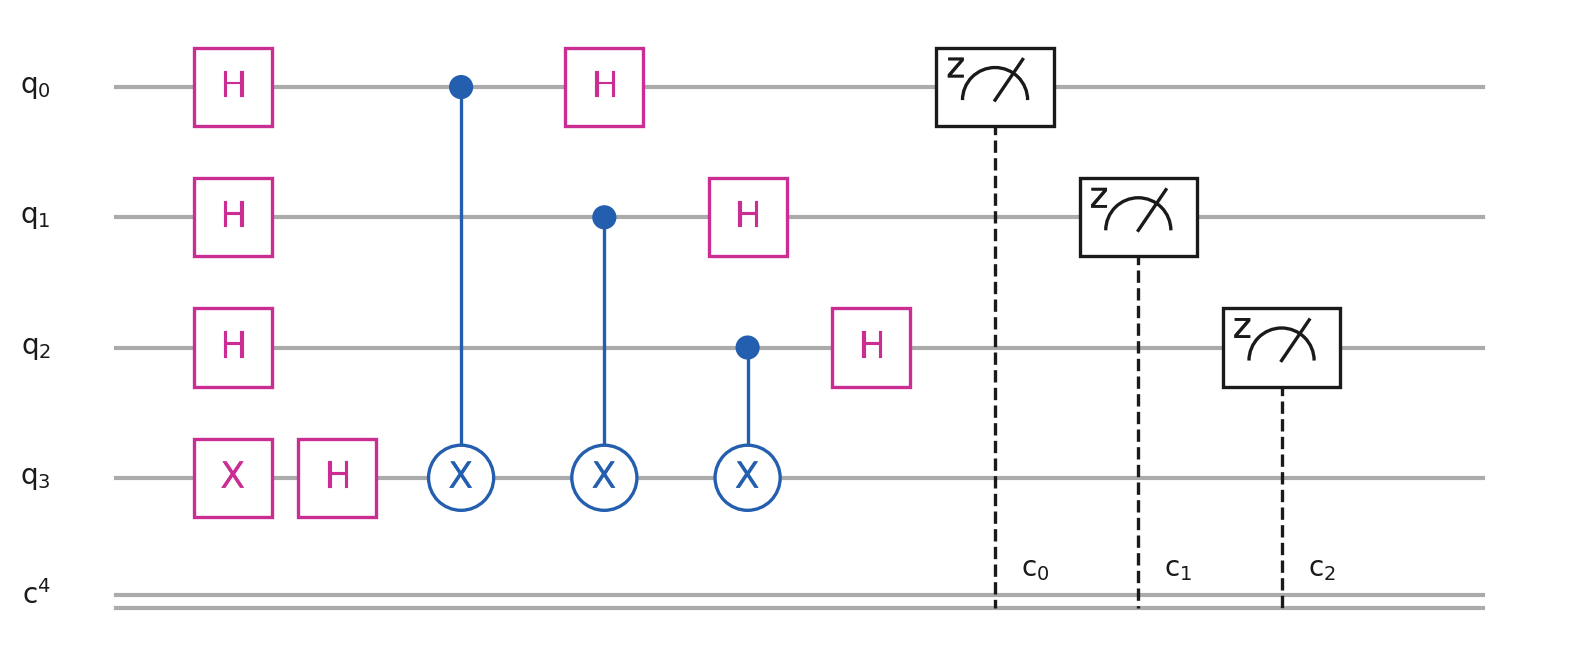

Gate stats: {'total_operations': 14, 'total_gates': 11, 'single_qubit_gates': 8, 'two_qubit_gates': 3, 'multi_qubit_gates': 0, 'clifford_gates': 11, 'non_clifford_gates': 0, 'parametric_gates': 0, 'measurements': 3, 'barriers': 0, 'gate_counts': {'X': 1, 'H': 7, 'CX': 3, 'MEASURE': 3}}


In [2]:
from qpiai_quantum import Circuit

n = 3  # number of input qubits

# We need n+1 qubits (n input + 1 ancilla) and n classical bits
qc = Circuit(n + 1, n)

ancilla = n  # last qubit is the ancilla

# ── Stage 1: Prepare ancilla in |−⟩ = H|1⟩ ──
# The ancilla must be in |−⟩ for phase kickback:
#   CX with target |−⟩ flips the phase of the control: |x⟩|−⟩ → (−1)^x |x⟩|−⟩
qc.x(ancilla)
qc.h(ancilla)

# ── Stage 2: Create uniform superposition on input register ──
# |0⟩^n → (1/√2^n) Σ_x |x⟩
for i in range(n):
    qc.h(i)

# ── Stage 3: Apply the balanced oracle ──
# f(x) = x_0 ⊕ x_1 ⊕ ... ⊕ x_{n-1}
# CNOT from each input qubit to the ancilla
for i in range(n):
    qc.cx(i, ancilla)

# ── Stage 4: Decode by applying Hadamard to input register ──
for i in range(n):
    qc.h(i)

# ── Stage 5: Measure input qubits ──
for i in range(n):
    qc.measure(i, i)

print("=== Manual DJ Circuit (balanced oracle, n =", n, ") ===")
qc.show()
print("Gate stats:", qc.list_gates())

### 3b. High-Level Construction with `DeutschJozsa`

The SDK provides a convenient `DeutschJozsa` class that wraps all five stages above. You simply specify the `oracle_type` and the class handles everything.

**Available oracle types:**
- `"constant_zero"`: $f(x) = 0$ for all $x$ (no gates on ancilla)
- `"constant_one"`: $f(x) = 1$ for all $x$ ($X$ gate on ancilla)
- `"balanced"`: $f(x) = x_0 \oplus x_1 \oplus \ldots \oplus x_{n-1}$ (CNOT from each input to ancilla)

Description: Deutsch-Jozsa Algorithm - determines if a boolean function is constant or balanced in a single query

=== DJ Circuit (high-level, balanced) ===


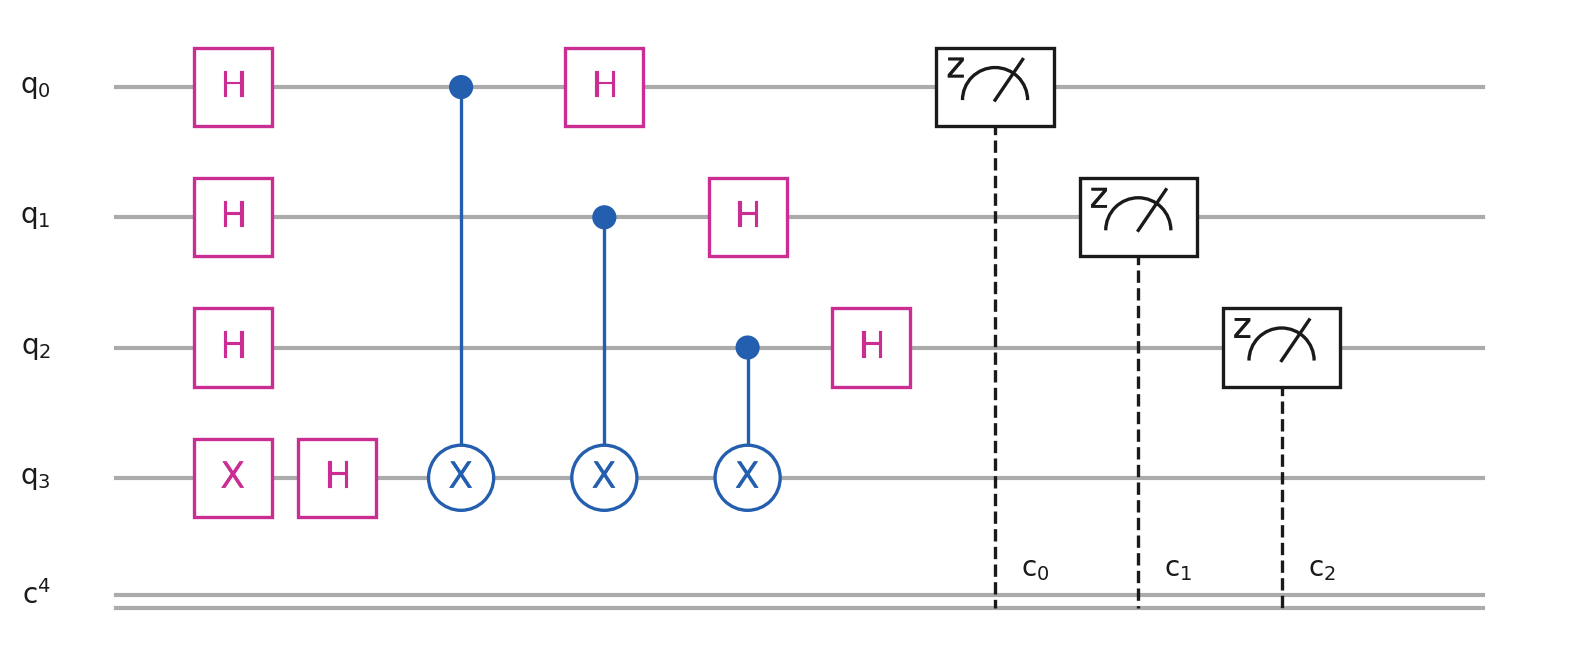

Gate stats: {'total_operations': 14, 'total_gates': 11, 'single_qubit_gates': 8, 'two_qubit_gates': 3, 'multi_qubit_gates': 0, 'clifford_gates': 11, 'non_clifford_gates': 0, 'parametric_gates': 0, 'measurements': 3, 'barriers': 0, 'gate_counts': {'X': 1, 'H': 7, 'CX': 3, 'MEASURE': 3}}


In [3]:
from qpiai_quantum.algorithms import DeutschJozsa

# Create a DeutschJozsa instance for the balanced oracle with 3 input qubits
dj = DeutschJozsa(num_qubits=3, oracle_type="balanced")
print("Description:", dj.description)

# Build the circuit
dj_circuit = dj.build_circuit()
print("\n=== DJ Circuit (high-level, balanced) ===")
dj_circuit.show()
print("Gate stats:", dj_circuit.list_gates())

### 3c. Theoretical Result

Before running, let's check what the algorithm **should** produce for each oracle type:

In [4]:
# Check theoretical results for all oracle types
for oracle_type in DeutschJozsa.VALID_ORACLE_TYPES:
    dj_temp = DeutschJozsa(num_qubits=3, oracle_type=oracle_type)
    theory = dj_temp.get_theoretical_result()
    print(f"Oracle: {oracle_type}")
    for key, value in theory.items():
        print(f"  {key}: {value}")
    print()

Oracle: constant_zero
  oracle_type: constant_zero
  expected_result: constant
  expected_counts: {'000': 1024}
  success_probability: 1.0
  num_oracle_queries: 1
  classical_queries_needed: 5 (worst case)
  speedup: exponential (1 query vs 2^(n-1)+1)

Oracle: constant_one
  oracle_type: constant_one
  expected_result: constant
  expected_counts: {'000': 1024}
  success_probability: 1.0
  num_oracle_queries: 1
  classical_queries_needed: 5 (worst case)
  speedup: exponential (1 query vs 2^(n-1)+1)

Oracle: balanced
  oracle_type: balanced
  expected_result: balanced
  expected_counts: {'111': 1024}
  success_probability: 1.0
  num_oracle_queries: 1
  classical_queries_needed: 5 (worst case)
  speedup: exponential (1 query vs 2^(n-1)+1)



## 4. Math: Why the Deutsch–Jozsa Algorithm Works

### The Full State Evolution

**Initial state:**  
$$|\psi_0\rangle = |0\rangle^{\otimes n} |0\rangle$$

**After Stage 1 (ancilla preparation):**  
$$|\psi_1\rangle = |0\rangle^{\otimes n} |-\rangle \quad \text{where } |-\rangle = \frac{|0\rangle - |1\rangle}{\sqrt{2}}$$

**After Stage 2 (Hadamard on inputs):**  
$$|\psi_2\rangle = \frac{1}{\sqrt{2^n}} \sum_{x \in \{0,1\}^n} |x\rangle \;|-\rangle$$

**After Stage 3 (oracle via phase kickback):**  
When the oracle acts on $|x\rangle|-\rangle$, the ancilla in $|-\rangle$ causes a phase flip:
$$U_f|x\rangle|-\rangle = (-1)^{f(x)} |x\rangle|-\rangle$$

So the full state becomes:
$$|\psi_3\rangle = \frac{1}{\sqrt{2^n}} \sum_{x} (-1)^{f(x)} |x\rangle \;|-\rangle$$

**After Stage 4 (Hadamard on inputs again):**  
Applying $H^{\otimes n}$ to the input register, and evaluating the amplitude of the all-zeros state $|0\rangle^{\otimes n}$:
$$\langle 0^n | H^{\otimes n} |\psi_3\rangle = \frac{1}{2^n} \sum_{x} (-1)^{f(x)}$$

- If $f$ is **constant**, all $(-1)^{f(x)}$ terms have the same sign, so the sum equals $\pm 1$ and the amplitude of $|0^n\rangle$ is $\pm 1$.
- If $f$ is **balanced**, half the terms are $+1$ and half are $-1$, so the sum equals $0$ and the amplitude of $|0^n\rangle$ is $0$.

**After Stage 5 (measurement):**

| Measurement outcome | Decision |
|---|---|
| $000\ldots0$ (all zeros) | **Constant** ✔ |
| Any non-zero bitstring | **Balanced** ✔ |

### Why Phase Kickback Works

The key trick is using the ancilla in $|-\rangle$. When the oracle targets $|-\rangle$:

$$U_f: |x\rangle|-\rangle \to (-1)^{f(x)} |x\rangle|-\rangle$$

The ancilla is **unchanged**, but the input register picks up a phase of $(-1)^{f(x)}$. This is phase kickback: the oracle's output is "kicked back" as a phase on the input register.

### Classical vs Quantum Complexity

| Property | Classical (deterministic) | Quantum (DJ) |
|---|---|---|
| Oracle queries needed | $2^{n-1} + 1$ (worst case) | $1$ |
| Query strategy | Test inputs one at a time | All inputs in superposition |
| Speedup | (baseline) | Exponential ($1$ query vs $2^{n-1}+1$) |

## 5. Experiment: Simulate and Verify

We will now run the Deutsch–Jozsa algorithm for **all three oracle types** and verify that the output correctly classifies each oracle as constant or balanced.

> **Simulator default:** `device_name="QpiAI-QSV-Local"`. To use a QPU, change `device_name` to `"QpiAI-Indus-1"` and configure an experiment with the same name in the QpiAI web UI.

> **Note:** The `experiment_name` parameter is omitted here because it is only required for cloud executions (e.g., on QCloud simulators or Indus QPU). For local simulation (`QpiAI-QSV-Local`), it is not needed.


In [5]:
# Test all three oracle types
oracle_types = ["constant_zero", "constant_one", "balanced"]
shots = 10_000

results = {}
for oracle_type in oracle_types:
    dj_inst = DeutschJozsa(num_qubits=3, oracle_type=oracle_type)
    dj_inst.build_circuit()

    print(f"\n=== Oracle: {oracle_type} (n=3) ===")
    # Note: experiment_name is only required for cloud executions
    res = dj_inst.run(
        shots=shots,
        device_name="QpiAI-QSV-Local",
    )
    counts = res.get_counts() or {}
    probs = res.get_probabilities() or {}
    results[oracle_type] = res

    print("Counts:", counts)
    print("Probabilities:", probs)

    # Interpret the result
    verdict = DeutschJozsa.interpret_result(res)
    expected = "constant" if "constant" in oracle_type else "balanced"
    match = "✅ CORRECT" if verdict == expected else "❌ WRONG"
    print(f"Verdict: {verdict} (expected: {expected}) {match}")


=== Oracle: constant_zero (n=3) ===
Counts: {'000': 10000}
Probabilities: {'000': 1.0}
Verdict: constant (expected: constant) ✅ CORRECT

=== Oracle: constant_one (n=3) ===
Counts: {'000': 10000}
Probabilities: {'000': 1.0}
Verdict: constant (expected: constant) ✅ CORRECT

=== Oracle: balanced (n=3) ===
Counts: {'111': 10000}
Probabilities: {'111': 1.0}
Verdict: balanced (expected: balanced) ✅ CORRECT



Plotting histogram for balanced oracle


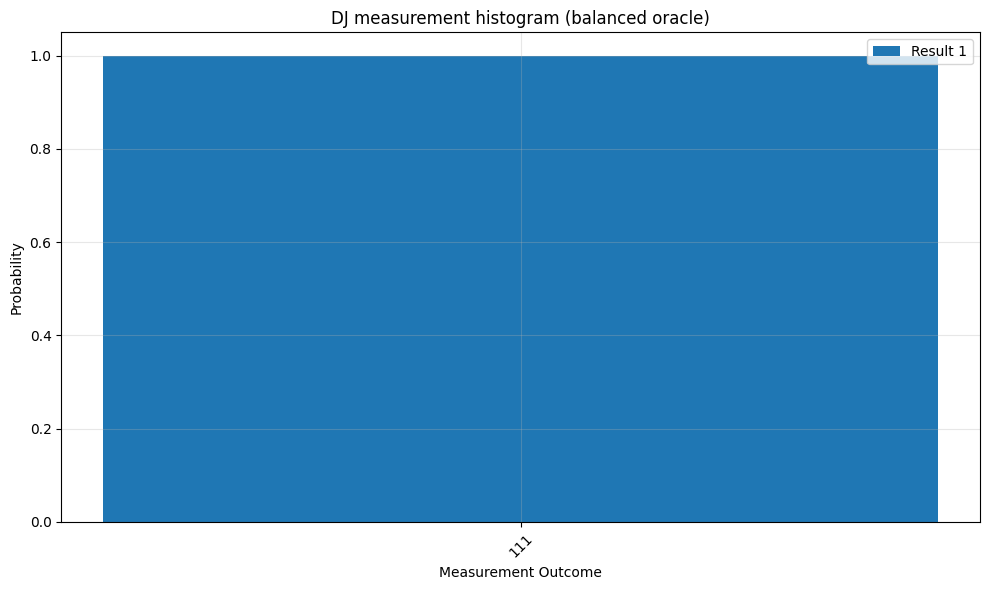

In [6]:
# Visualize the histogram for the balanced oracle
print("\nPlotting histogram for balanced oracle")
results["balanced"].plot(title="DJ measurement histogram (balanced oracle)")


Plotting histogram for constant_zero oracle


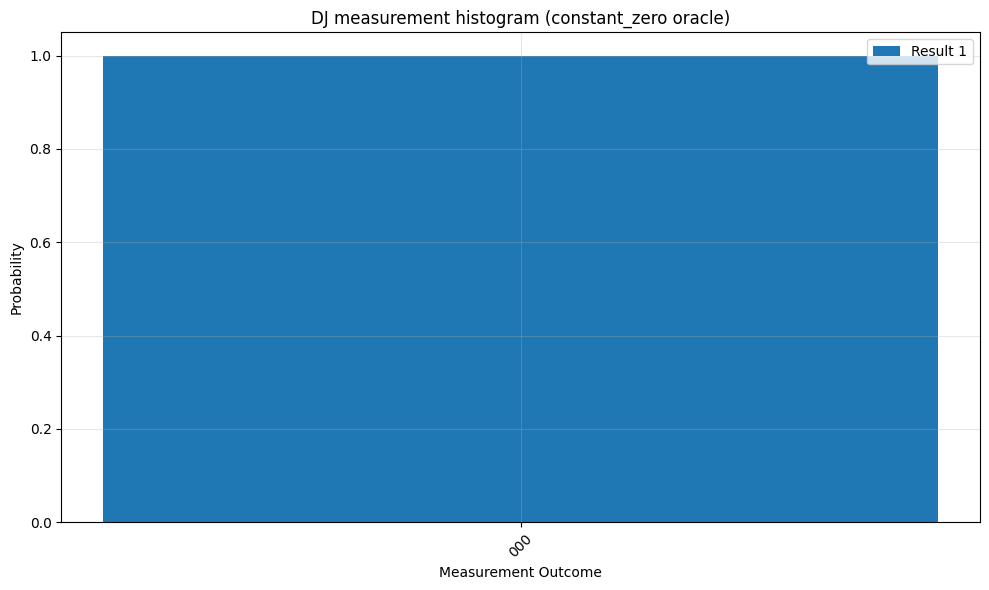

In [7]:
# Visualize the histogram for the constant_zero oracle
print("\nPlotting histogram for constant_zero oracle")
results["constant_zero"].plot(title="DJ measurement histogram (constant_zero oracle)")

### Results Interpretation

In the ideal (noiseless) case, you should observe:

- **Constant oracles** (`constant_zero`, `constant_one`): A single peak at `000` with 100% probability. All shots land on the all-zeros outcome.
- **Balanced oracle**: A single peak at a **non-zero** bitstring (e.g., `111`) with 100% probability.

**Decision rule:**
- If all measured qubits are $0$ → the function is **constant**.
- If any measured qubit is $1$ → the function is **balanced**.

This confirms the DJ algorithm's key property: **one oracle query suffices to classify the function with certainty**.

### Using `determine_function_type()` for Convenience

The `DeutschJozsa` class also provides a `determine_function_type()` method that builds the circuit, runs it, and directly returns whether the function is `"constant"` or `"balanced"`.

In [8]:
for oracle_type in ["constant_zero", "constant_one", "balanced"]:
    dj_auto = DeutschJozsa(num_qubits=4, oracle_type=oracle_type)
    result_type = dj_auto.determine_function_type(shots=1024)
    expected = "constant" if "constant" in oracle_type else "balanced"
    match = "✅" if result_type == expected else "❌"
    print(f"Oracle: {oracle_type:16s}  =>  {result_type:10s} (expected: {expected}) {match}")

Oracle: constant_zero     =>  constant   (expected: constant) ✅
Oracle: constant_one      =>  constant   (expected: constant) ✅
Oracle: balanced          =>  balanced   (expected: balanced) ✅


## 6. Exercises

**Beginner:**

1. Run the Deutsch–Jozsa algorithm with `oracle_type="constant_one"`. What measurement outcome do you expect? Verify by running the circuit.
2. Try different numbers of input qubits (e.g., $n = 1, 2, 4, 5$). Does the algorithm always produce the correct verdict in a single run?

**Intermediate:**

3. Build the DJ circuit manually (using `Circuit`) for a **constant_one** oracle with $n = 2$ and display it with `show()`. Compare it to the balanced oracle circuit: what is different in the oracle stage?
4. Compare the theoretical result from `get_theoretical_result()` with the experimental result from `run()`. How do they differ on the simulator?

**Advanced:**

5. **Custom balanced oracle:** Design a balanced oracle where only qubit 0 controls the ancilla (i.e., $f(x) = x_0$). Is this function balanced? Build the circuit manually and run it.
6. Prove mathematically that measuring all zeros implies $f$ is constant. *(Hint: use the expression for the amplitude $\langle 0^n | H^{\otimes n} \frac{1}{\sqrt{2^n}} \sum_x (-1)^{f(x)} |x\rangle$ and argue using the promise that $f$ is constant or balanced.)*

## 7. Key Takeaways

- The **Deutsch–Jozsa algorithm** determines whether a boolean function is constant or balanced in **1 oracle query**, compared to $2^{n-1}+1$ classically.
- The core mechanism is **phase kickback**: the ancilla in $|-\rangle$ causes the oracle's output to be encoded as a phase on the input register.
- Two rounds of **Hadamard transforms** (create superposition → decode phase) combined with **interference** convert the global property of $f$ into a single deterministic measurement.
- The QpiAI SDK provides both a **low-level `Circuit` API** for manual construction and a **high-level `DeutschJozsa` class** with methods like `build_circuit()`, `run()`, `determine_function_type()`, `interpret_result()`, and `get_theoretical_result()`.
- On the **statevector simulator**, the result is exact (one peak). On real hardware, noise may introduce small errors, but the correct answer remains the dominant outcome.

---
**Thank you for learning with QpiAI!**

In [9]:
import qpiai_quantum
print(qpiai_quantum.__version__)

0.1.34
